In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class BasicNN(nn.Module):
    def __init__(self):
        
        super().__init__()
        
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.00), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.70), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16.0), requires_grad=False)

    def forward(self, input):
        
        input_to_top_relu = (input * self.w00) + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w01

        input_to_bottom_relu = (input * self.w10) + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

In [3]:
input_doses = torch.linspace(start=0, end=1, steps=11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [4]:
model = BasicNN()

output_values = model(input_doses)

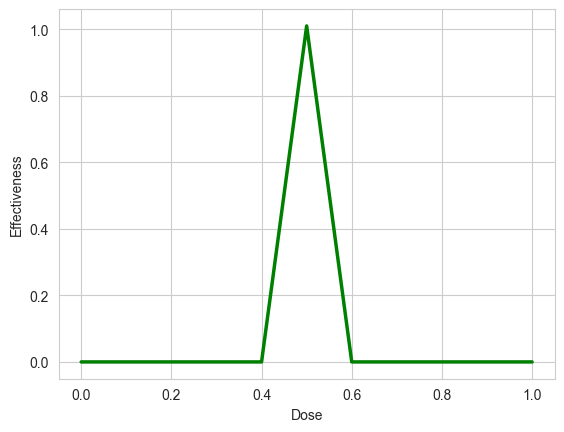

In [5]:
sns.set_style(style="whitegrid")
sns.lineplot(x=input_doses, y=output_values, color="green", linewidth=2.5)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")
plt.show()

In [6]:
class BasicNN_Train(BasicNN):
    def __init__(self):
        super().__init__()
        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

In [7]:
model2 = BasicNN_Train()

output_values2 = model2(input_doses)

Text(0.5, 0, 'Dose')

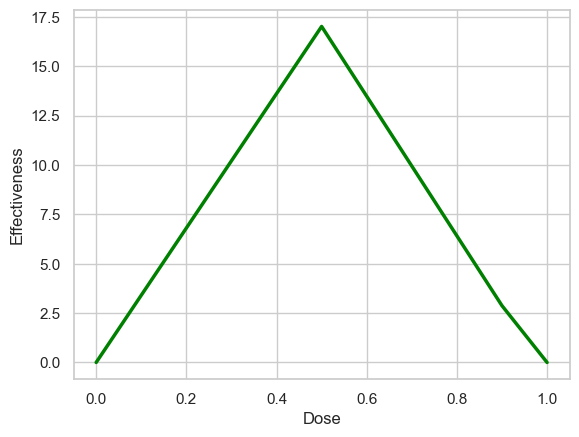

In [8]:
sns.set_theme(style="whitegrid")
sns.lineplot(
    x=input_doses,
    y=output_values2.detach(),
    color="green",
    linewidth=2.5
)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")

In [9]:
inputs = torch.tensor([0.0, 0.5, 1.0])
labels = torch.tensor([0.0, 1.0, 0.0])

In [10]:
optimizer = SGD(model2.parameters(), lr=0.1)
print(f"Final Bias, before optimization: {model2.final_bias.data}")

Final Bias, before optimization: 0.0


In [11]:
for epoch in range(100):
    total_loss = 0
    for iteration in range(len(inputs)):
        input_i = inputs[iteration]
        label_i = labels[iteration]
        output_i = model2(input_i)

        loss = (output_i - label_i)**2  
        loss.backward()
        total_loss += float(loss)
    
    if total_loss < 0.0001:
        print(f"Num Steps: {epoch}")
        break

    optimizer.step()
    optimizer.zero_grad()

    print(f"Step: {epoch} Final Bias: {model2.final_bias.data}")

Step: 0 Final Bias: -3.202000141143799

Step: 1 Final Bias: -5.7636003494262695

Step: 2 Final Bias: -7.812880516052246

Step: 3 Final Bias: -9.45230484008789

Step: 4 Final Bias: -10.763843536376953

Step: 5 Final Bias: -11.813075065612793

Step: 6 Final Bias: -12.652460098266602

Step: 7 Final Bias: -13.323967933654785

Step: 8 Final Bias: -13.861174583435059

Step: 9 Final Bias: -14.290939331054688

Step: 10 Final Bias: -14.634751319885254

Step: 11 Final Bias: -14.909801483154297

Step: 12 Final Bias: -15.129840850830078

Step: 13 Final Bias: -15.305872917175293

Step: 14 Final Bias: -15.446698188781738

Step: 15 Final Bias: -15.559358596801758

Step: 16 Final Bias: -15.649486541748047

Step: 17 Final Bias: -15.721589088439941

Step: 18 Final Bias: -15.779271125793457

Step: 19 Final Bias: -15.825416564941406

Step: 20 Final Bias: -15.862333297729492

Step: 21 Final Bias: -15.891866683959961

Step: 22 Final Bias: -15.91549301147461

Step: 23 Final Bias: -15.934394836425781

Step: 2

Text(0.5, 0, 'Dose')

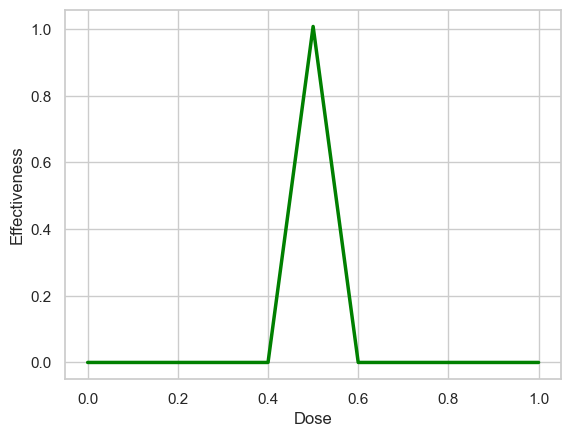

In [13]:
output_values3 = model2(input_doses)

sns.set_theme(style="whitegrid")
sns.lineplot(
    x=input_doses,
    y=output_values3.detach(),
    color="green",
    linewidth=2.5
)
plt.ylabel("Effectiveness")
plt.xlabel("Dose")